## T2: Simple Chain
In this tutorial, we will be extending the things we learnt in the tutorial on Rabi oscillations in the two-level system to a simple chain. We will use tight-binding to describe the electronic structure and make a pulse go through said chain. 

We define the hopping parameter, repetitions, and energy-sampling of the self energies and sisl-geometries.


/home/investigator/.local/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_lattice']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/home/investigator/.local/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_positions']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/home/investigator/.local/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['std_types']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/home/investigator/.local/lib/python3.10/site-packages/spglib/spglib.py:115: DeprecationWarning: dict interface (SpglibDataset['number']) is deprecated.Use attribute interface ({self.__class__.__name__}.{key}) instead
  warnings.warn(
/home/investigator/.local/lib/python3.10/site

Normal plot


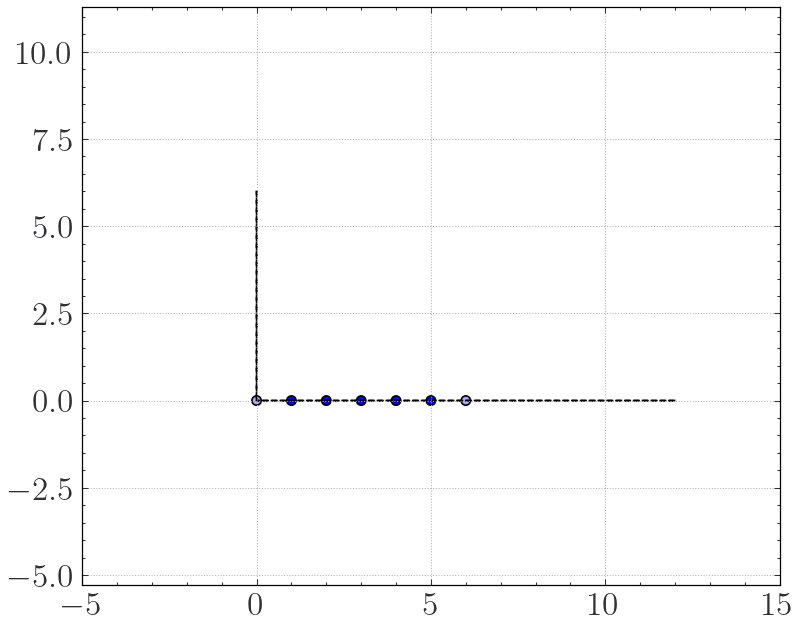

In [1]:
import numpy as np
import sisl
import matplotlib.pyplot as plt
from Zandpack.TimedependentTransport import TD_Transport as TDT
import matplotlib.image as img
  

tx = 5
t_dev =  1
t_elec = 1

lat_const = 1.0
line = np.linspace(-2.5 , 2.5, 101)  + 1j*1e-2 # line = Evec + 1j*eta
line = np.vstack((line,line))

### Geometries ###
geom_dev   = sisl.geom.sc(lat_const, 'H').tile(tx+2, 0)
geom_ep    = sisl.geom.sc(lat_const, 'H').tile(1, 0).move(np.array([lat_const * (tx+1), 0, 0]))
geom_em    = sisl.geom.sc(lat_const, 'H').tile(1, 0)
geom_dev   = geom_dev.add_vacuum(5,1).add_vacuum(5,2).add_vacuum(5,0)
geom_em    = geom_em. add_vacuum(5,1).add_vacuum(5,2)
geom_ep    = geom_ep. add_vacuum(5,1).add_vacuum(5,2)

### Our Main calculator object ###
C = TDT([geom_em,geom_ep], geom_dev, kT_i = [0.025, 0.025])
C.Make_Contour(line, 20 ,pole_mode = 'JieHu2011')
C.Electrodes( semi_infs = ['-a1', '+a1'] )
C.make_device(elec_inds = [[0],  [tx+1]] )

plt.show()
C.Device.Visualise()

Now we make the electronic structures:

In [2]:
# Create the electronic structures. These are sisl shorthands for creating the Hamiltonians of the leads and device
elec = sisl.Hamiltonian(sisl.geom.sc(lat_const, sisl.Atom(1, R= 1.1),).add_vacuum(10,1).add_vacuum(10,2), orthogonal=False)
elec.construct([[0.1, lat_const * 1.1], 
                [(0.0, 1.0), (t_elec, 1e-3)]])

dev_H = sisl.Hamiltonian(sisl.geom.sc(lat_const, sisl.Atom(1, R= 1.1)).tile(tx+2,0).add_vacuum(10,1).add_vacuum(10,2).add_vacuum(10,0),
                         orthogonal=False)
dev_H.construct([[0.1, lat_const * 1.1 ], 
                 [(0, 1), (t_dev, 1e-3)]])
print(elec.nsc)
print(lat_const)
print(elec[0,0, (1,0,0)])

[3 1 1]
1.0
[1.    0.001]


Running TB-Trans in Directory: Device!



warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].
warn:0: SislWarning: tbtsencSileTBtrans.Eindex handles int's the same as floats [>0.15.2].

Calculating corrections for electrode 0. (Normal electrode)
Calculating corrections for electrode 1. (Normal electrode)

 Building ES - H - Self Energies 

[0]
Using S = S

 Overlap Included!



/home/investigator/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/investigator/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


array([[1, 1, 1, 0, 0],
       [1, 1, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0]])

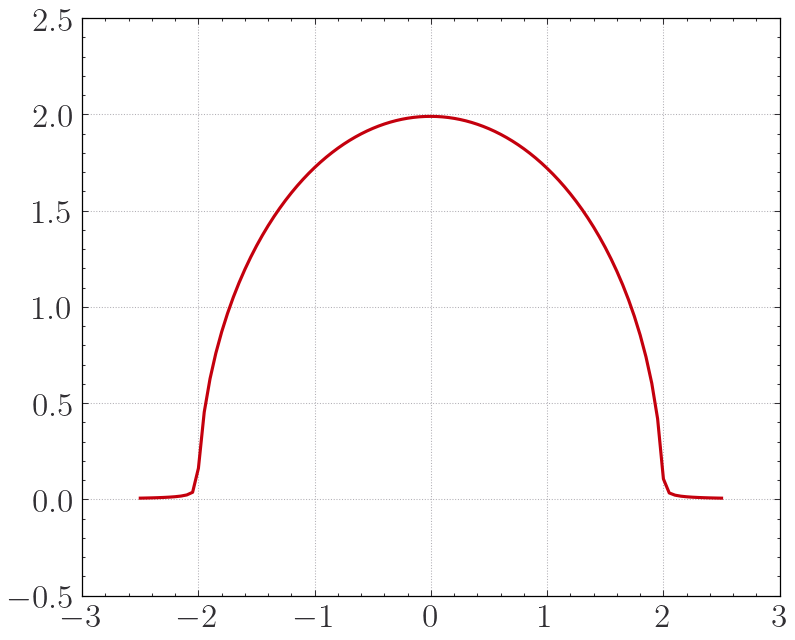

In [3]:
# Run TBtrans and read in data
C.run_electrodes(manual_H = [elec, elec])
C.run_device(manual_H = dev_H)
C.read_data()
plt.plot(C.Contour[C.sampling_idx[0]],C.Ortho_Gammas[0].Block(0,0)[0,C.sampling_idx[0],0,0])
C.Ortho_Gammas[0].is_zero

We now plot the transmissions and density of states of the device region.

### Fitting of the self-energies
Now we have the electronic structures of the leads and device. Contrary to the previous tutorial on Rabi-oscillations, the selfenergies are now non-zero. We therefore have to put some effort into fitting these to sums of Lorentzian functions. The fitting function called as "Fit" on our calculator object,  and the keywords for it are elabored on below:

In [53]:
NL = 11
def run_fit(its):
    C.Fit(fact = .66,             # a number controlling the broadening on the initial guess
          NumL = NL,               # number of Lorentzians used for the fitting
          ebounds = (-2.75,2.75),       # bounds on where the Lorentzian centers can be located
          wbounds = (0.3, 10.0), # bounds on the linewidths of the Lorentzians
          gbounds = (None, None), # bounds on the fitting coefficients
          options = {'disp':True, # options keywords passed to the SciPy minimizer. The the docs for more info
                     'maxiter':its,   
                     'gtol':1e-5, 
                    # 'iprint':5
                    },
          force_PSD    = True,
          force_PSD_tol=[min_tol1, min_tol2],
          #specific_bounds = None,#[{(0 ,5) :[(-0.1, 0.1), (4,5)]}, {(0 ,5) :[(-0.1, 0.1), (4,5)]}], 
          alpha_PO = 0.001,
          min_method='SLSQP'
         )


Before we run the fitting, it should we noted that the fitting can be reset and continued as will be demonstrated. There are also a couple of more keywords which are not gonna be used for now. 

In [54]:
C.reset_all_fits() # Comment this in to reset fit
                   # Try to rerun this cell
                   # You can also fiddle with the positions and broadenings
                   # of the Lorentzians after they've been fitted. This is for another tutorial

min_tol1, min_tol2 = np.zeros((1,NL)), np.zeros((1,NL))
min_tol1[:,:] = -100.0
min_tol2[:,:] = -100.0

run_fit(100)


# Lastly run it with its = 200 or so to the the fit

Finding Lambda matrices:
False

--------------------
Optimizing Lorentzian Expansion
--------------------

1
#Variables optimized for: 22
F,it =  0.0819, 4
F,it =  0.07948, 8
F,it =  0.07938, 12
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.07938189121526076
            Iterations: 12
            Function evaluations: 13
            Gradient evaluations: 12
Lorentzian fit took 0.016516447067260742 seconds.
Finding Lambda matrices:
False

--------------------
Optimizing Lorentzian Expansion
--------------------

1
#Variables optimized for: 22
F,it =  0.0819, 4
F,it =  0.07948, 8
F,it =  0.07938, 12
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.07938189121526076
            Iterations: 12
            Function evaluations: 13
            Gradient evaluations: 12
Lorentzian fit took 0.017865419387817383 seconds.


We now have our fit for the self energies. How well does it fit? There are some shorthand functions for this. Many of them start with Inspect_.... and we will take a look at a couple of them. 

Firstly, how well does the fitted self energies reproduce the transmission obtained from tbtrans?

Text(0.5, 0, 'Energy')

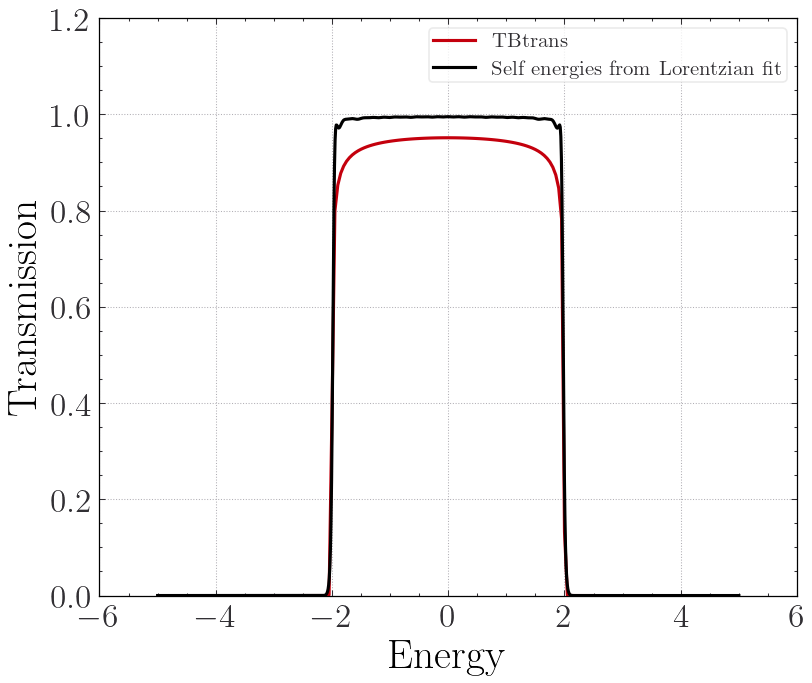

In [55]:
# Try changing eta, what did we set it to in the initial transport calculation?
C.Inspect_transmission_from_hilbert_transform(E=np.linspace(-5,5,1000),eta=1e-3)
plt.ylabel('Transmission',size=20); plt.xlabel('Energy',size=20)

Pretty Well! It is also just a chain so it is not hard to fit the self-energies and get good agreement between the fitted self-energies and actual sampled self energies. But say we want to find out how well each matrix-element fits. There is a function for this also, which we will use shortly. First we just need to know a bit about how the matrix elements are stored. TBtrans outputs the matrix elements together with a way to write the inverse of the Green's function of the device region on block-tridiagonal form. This allows for very efficient calculations on large structures. This scheme is retained for this code, meaning whenever we want to inspect a matrix element, we have to specify the block and the indices within the block, together with a lead index:

 Self energy 1 block structure:

 Self energy 2 block structure:


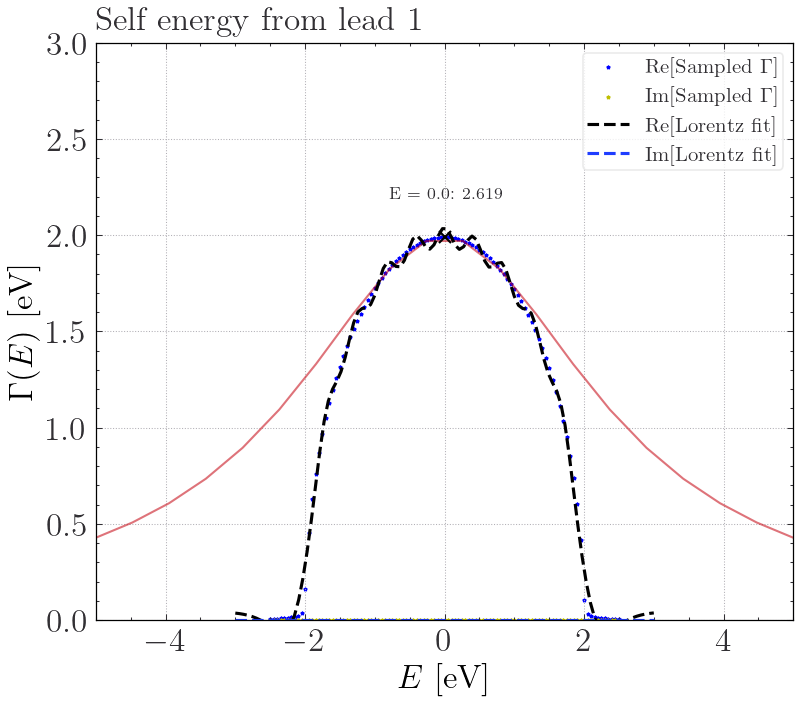

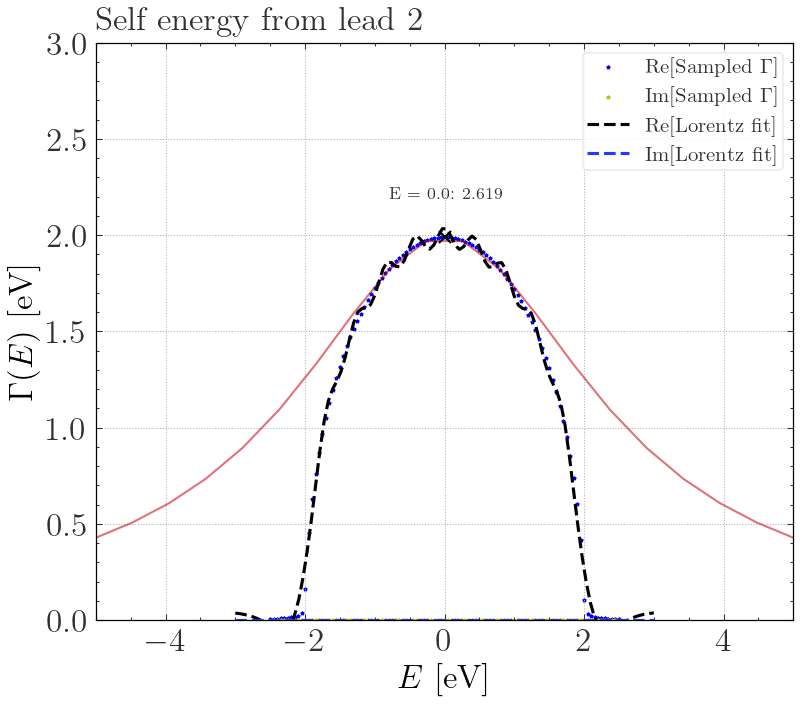

Minimum distance from Fermi-poles to Lorentzian poles: 0.06438448069540999/n
Minimum distance between Lorentzian poles: 0.41693281031634305/n
Minimum value of imaginary part of Lorentzian poles: 0.3


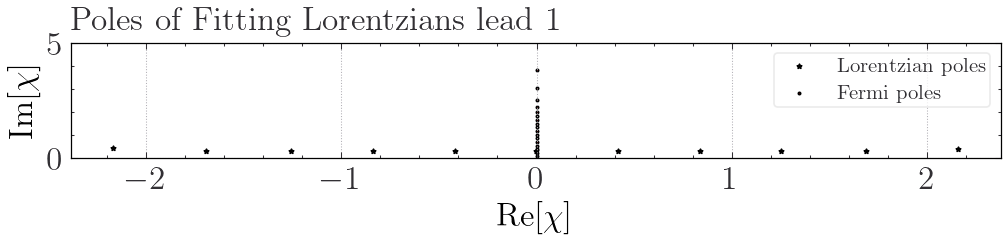

Minimum distance from Fermi-poles to Lorentzian poles: 0.06438448069540999/n
Minimum distance between Lorentzian poles: 0.41693281031634305/n
Minimum value of imaginary part of Lorentzian poles: 0.3


(0.0, 5.0)

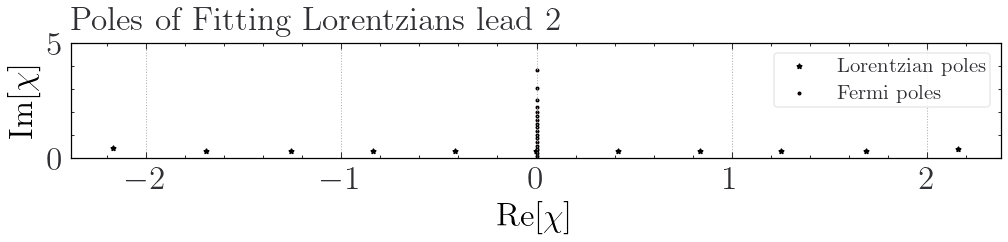

In [56]:
print(' Self energy 1 block structure:')
#print(C.fitted_self_energies[0].is_zero)
print('\n Self energy 2 block structure:')
#print(C.fitted_self_energies[1].is_zero)

                            #Lead_idx,  block_i,  block_j, idx_i,   idx_j
C.Inspect_Lorentzian_fit(0,          0,        0,       0,       0    ); plt.title('Self energy from lead 1')
plt.xlim(-5,5)
plt.ylim(0, 3)
C.Inspect_Lorentzian_fit(1,          4,        4,       0,       0    ); plt.title('Self energy from lead 2')
plt.xlim(-5,5)
plt.ylim(0, 3)

plt.show()
C.Inspect_Poles(0); plt.title('Poles of Fitting Lorentzians lead 1'); plt.ylim([0,5])
plt.show()
C.Inspect_Poles(1); plt.title('Poles of Fitting Lorentzians lead 2'); plt.ylim([0,5])


We do as in the two-level example: Define lead bias and the timedependent correction to the Hamiltonian. We start out with getting the system to steady state. Shorthand functions for this are available in the Pulses module.

In [63]:
from Zandpack.Pulses import zero_bias, zero_dH
C.tofile('Chain')
C.Check_input_to_ODE()

Finding eigenvalues and eigenvectors
Maximum of eigenvalues of Lorentzian Gammas: 1.024467
Minimum of eigenvalues of Lorentzian Gammas: -0.424475
If the minimum is negative, you should take extra care!
( if minimum negative Check eigenvalues of $\Gamma$)

 Check the ODECheck.txt file lying in the working directory!


 The values in the file should be small!



We now have the "Chain" folder in the directory! There are already the Bias.py and Initial.py files lying in this directory, so we can just run SuperZand.

     - Modify "eps" in Initial.py until you have a converged result (1e-12 will definitely(!) do)
     - Modify Bias.py to your liking
     - Look through the output of the calculation. This has additional information
     - Tip, The current files to not get deleted, so sometimes if you get some funny current curves,
       delete the Chain_save folder and redo the calculation


In [64]:
!mpirun -np 3 zand Dir=$PWD

Warning from RK4pars: Something went wrong with loading k0nfig
Warning from RK4pars: Something went wrong with loading k0nfig
Warning from RK4pars: Something went wrong with loading k0nfig

  
  ▂▃▄▅▆▇█▓▒░zand (v. 1.0)░▒▓█▇▆▅▄▃▂
  
  Program developed for time-dependent transport in nanostructures 
  at the Technical University of Denmark (DTU).
  
  Please cite this article:
       ***Cool Article Bibtex***  

  
  Author: Aleksander Bach Lorentzen, DTU ( aleksander.bach@dipc.org / aleksander.bl.mail@gmail.com )
  Supervisor: Prof. Mads Brandbyge, DTU.
    - Dr. Nick Papior from DTU compute has constributed with performance tips.
    - Dr. Alexander Croy from Friedrich Schiller University has contributed 
      with methods for consistency checks and steadystate solution. 


  Visit Github.com/AleksBL/?? for tutorials.
  
  Basic function of this program:
  There are two scripts that needs to accompany this program:
 
  The "Initial.py" script, which has the information of the 
  init

td_info Program Start

sys.argv: ['/home/investigator/Desktop/Code/PythonModules/Zandpack/Zandpack/cmdtools/td_info', 'Dir=/home/investigator/Desktop/TD_stuff/nb_tutorial/TightBinding/T2_TB_Chain', 'file=Chain', 'plotcurrent=1', 'label=Current', 'format=png', 'tmin=-15', 'tmax=25']

[0]
Figure(900x750)


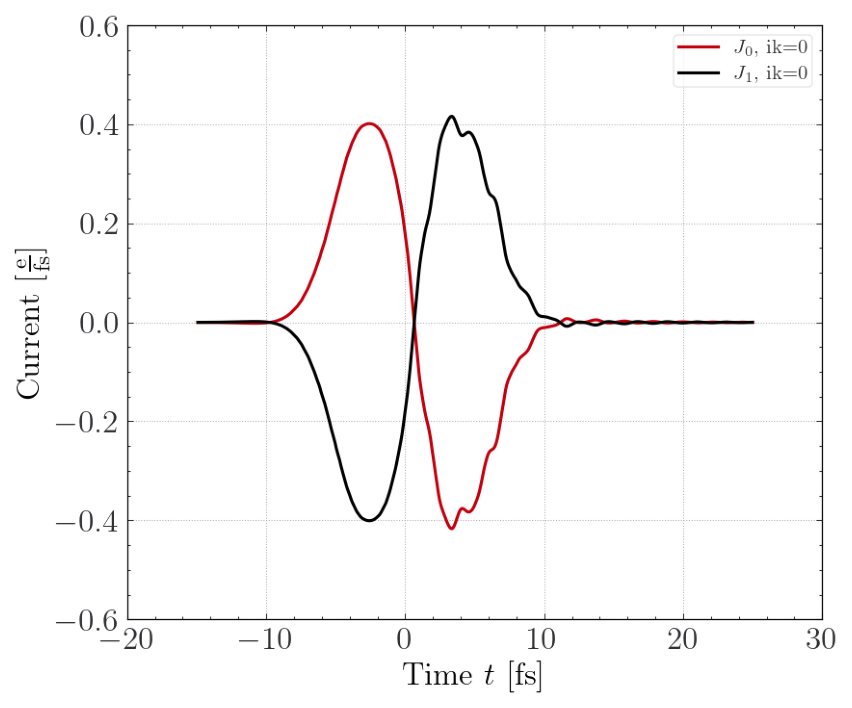

In [65]:
!td_info Dir=$PWD file=Chain plotcurrent=1 label=Current format=png tmin=-15 tmax=25
im = img.imread('CurrentCurrentplot.png')
plt.rcParams['figure.figsize']=(10,6)
plt.axis('off')
plt.imshow(im)

We have now converged this simple calculation. Great! But, you might noticing the code is not starting out very fast, this is because the initial condition we have set is not the steady state of the system. Here we just propagate the system until we get to the steady-state because it is not so computationally expensive, but it is possible to find the actual steady-state without doing this. It is for another tutorial, but the SCF & psinought codes are meant for this job.  




     -  Try now to put in the bias and dH functions below and do the calculation again!
     -  Tune the amplitude, t0,t1, etc. 

In [ ]:
s = 5
A = 0.5
w = 0.05
def Pulse(t):
    return A*np.exp(-(t/s)**2)*np.sin(2*np.pi*w*t)

def bias(t,a):
    if a==0: return -Pulse(t)
    if a==1: return +Pulse(t)
X = np.load('Chain/Arrays/Positions.npy')[np.load('Chain/Arrays/pivot.npy'),0] 
# Remember the pivot here because tbtrans may have switched some rows
# the electrode incices has also been removed in pivot
tx = len(X)/2
def dH(t, sig):
    A  = np.zeros(sig.shape,dtype = np.complex128)
    xm = tx/2
    A[0,:,:] = -np.diag(2*(X-xm)/(X.max() - X.min())) * Pulse(t)
    return A
